## 3DoF Entry Cobra w/o Aoa SCP

Imports

In [1]:
# Basic imports
import importlib
import numpy                as np
import matplotlib.pyplot    as plt
import pandas               as pd
import copy

# Trajopt imports --> pip install -e ~/ACL/trajopt
import trajopt; importlib.reload(trajopt)
import trajopt.core.modules.method.scp              as scp
import trajopt.core.problem                         as prob
import trajopt.utils.config_loader                  as cfg
import trajopt.utils.tools                          as tools
import trajopt.analysis.default_analysis            as default_analysis
import trajopt.analysis.statistics                  as stats
import trajopt.core.modules.analysis.monte_carlo    as mc
import trajopt.core.modules.analysis.standalone     as standalone

from trajopt.analysis.trajplots import *

np.random.seed(0)  # for reproducibility



In [2]:
example_name = "lander_6dof"
method_name = "standard"
nominal_config  = cfg.load_configs(example_name)

# create problem instance
problem = prob.Problem(nominal_config)

# run SCP
problem = scp.run_scp(problem)

# store scenario data struct for plotting
scenario_data = standalone.run_standalone_analysis(problem, method_name)

scales: 
d: 1.0000, t: 1.0000, m: 1.0000, v: 1.0000, a: 1.0000, f: 1.0000, ang: 57.2958, angv: 57.2958, none: 1.0000


/Users/carlosm/Documents/guidance/hypersonics/trajopt/src/trajopt/core/modules/method/convergence.py:83: RuntimeWarning: invalid value encountered in divide
  Wconv_ineq = np.diag(eps_min_ineq / eps_ineq_nd) if eps_ineq_nd.size > 0 else np.zeros((1,1))


Cost initial: 0.0
--------------------------------------------------------------------------------------------------------------------------------------------------------
                                              ..:: lander: PTR with Virtual Buffer ::..
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Iteration |  Propagation |   Solve   |    Parse   |  log(dz)  |      log(VB)    |   log(VB)   |  log(VB)    | Solve status |  Time of    |   Cost    
            |   time [ms]  | time [ms] |  time [ms] |           |  (path + NFZ)   |  (terminal) |  (dynamics) |              |  Flight [s] |           
--------------------------------------------------------------------------------------------------------------------------------------------------------


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain.py:241: UserWarning: You are solving a parameterized problem that is not DPP. Because the problem is not DPP, subsequent solves will not be faster than the first one. For more information, see the documentation on Disciplined Parametrized Programming, at https://www.cvxpy.org/tutorial/dpp/index.html
  warnings.warn(DPP_ERROR_MSG)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


     01     |    01305.3   |   0013.3  |   0683.2   |   -3.4    |      -12.0      |    -12.0    |     -01.2   |    optimal    |   4.50   |   0.0
     02     |    00008.9   |   0011.9  |   0577.4   |   -0.9    |      -12.0      |    -12.0    |     -01.3   |    optimal    |   4.00   |   0.0
     03     |    00008.3   |   0024.5  |   0506.0   |   +0.1    |      -12.0      |    -12.0    |     -02.1   |    optimal    |   3.82   |   0.0
     04     |    00008.0   |   0018.1  |   0585.5   |   -0.4    |      -12.0      |    -12.0    |     -03.7   |    optimal    |   4.30   |   0.0
     05     |    00008.2   |   0019.6  |   0567.9   |   -1.0    |      -12.0      |    -12.0    |     -04.4   |    optimal    |   4.14   |   0.0
     06     |    00007.7   |   0018.1  |   0574.3   |   -1.9    |      -12.0      |    -12.0    |     -04.7   |    optimal    |   4.12   |   0.0
     07     |    00007.8   |   0018.7  |   0579.7   |   -3.4    |      -12.0      |    -12.0    |     -05.2   |    optimal    |   

In [3]:
# Direction Cosine Matrix Function
def DCM(q): 
    return np.array(
        [
            [
                1 - 2 * (q[2] ** 2 + q[3] ** 2),
                2 * (q[1] * q[2] + q[0] * q[3]),
                2 * (q[1] * q[3] - q[0] * q[2]),
            ],
            [
                2 * (q[1] * q[2] - q[0] * q[3]),
                1 - 2 * (q[1] ** 2 + q[3] ** 2),
                2 * (q[2] * q[3] + q[0] * q[1]),
            ],
            [
                2 * (q[1] * q[3] + q[0] * q[2]),
                2 * (q[2] * q[3] - q[0] * q[1]),
                1 - 2 * (q[1] ** 2 + q[2] ** 2),
            ],
        ]
    )


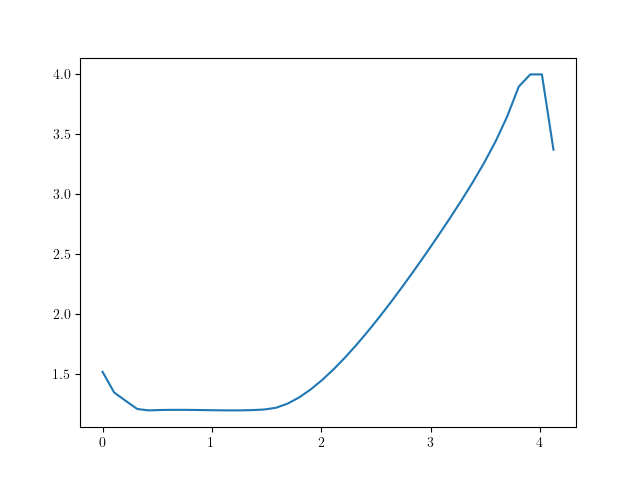

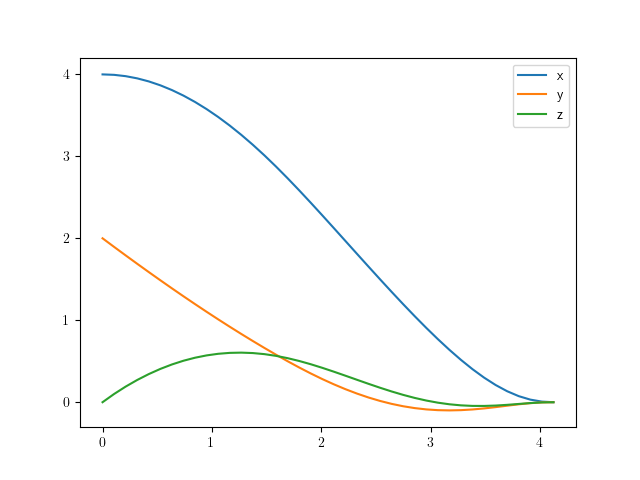

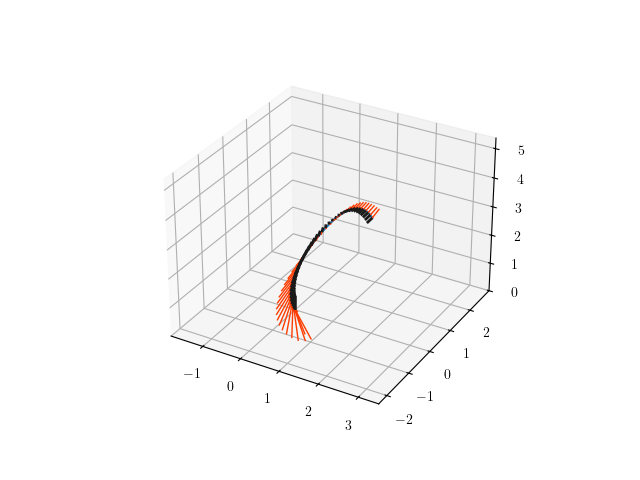

In [5]:
import matplotlib.pyplot as plt
%matplotlib ipympl
matplotlib.rcParams['axes3d.mouserotationstyle'] = 'azel'

soln = scenario_data['standard']['mc_data'][0]['iters'][-1]

t_opt = soln['t_opt']
z_opt = soln['z_opt']
nu_opt = soln['nu_opt']

DCMs = np.empty((problem.method.N, 3, 3))
u_vecs = np.empty_like(nu_opt[:, :problem.model.m])
rt_I = np.zeros((problem.method.N, 3))
body_vecs = np.zeros((problem.method.N, 3))

veh = problem.mission.vehicle
rt = np.array([veh["rt1"], veh["rt2"], veh["rt3"]])

for i in range(problem.method.N):
    DCMs[i] = DCM(z_opt[i, 7:11])

    u_vecs[i] = 0.3* DCMs[i].T @ nu_opt[i, :problem.model.m]
    rt_I[i] = DCMs[i].T @ rt
    body_vecs[i] = 0.5 * DCMs[i].T @ np.array([1, 0, 0])

# # position plots
plt.figure()
plt.plot(t_opt, z_opt[:, 1], label='x')
plt.plot(t_opt, z_opt[:, 2], label='y')
plt.plot(t_opt, z_opt[:, 3], label='z')
plt.legend()

# 3D position plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(z_opt[:, 2], z_opt[:, 3], z_opt[:, 1])
ax.quiver3D(z_opt[:, 2], z_opt[:, 3], z_opt[:, 1], body_vecs[:, 1], body_vecs[:, 2], body_vecs[:, 0],
            normalize=False,
            arrow_length_ratio=0,
            color=(0.1, 0.1, 0.1),
            linewidth=2.0)

ax.quiver3D(z_opt[:, 2] - u_vecs[:, 1],
             z_opt[:, 3] - u_vecs[:, 2],
             z_opt[:, 1] - u_vecs[:, 0],
            u_vecs[:, 1], u_vecs[:, 2], u_vecs[:, 0],
            normalize=False,
            arrow_length_ratio=0.1,
            color=(1, 60/255, 0),
            linewidth=1)

# PLOT ASPECT RATIO FIXING (NEEDS TO BE DONE MANUALLY FOR 3D PLOTS :( )

# fix aspect ratio of 3d plot
x_lim = ax.get_xlim3d()
y_lim = ax.get_ylim3d()
z_lim = ax.get_zlim3d()

max_lim = max(abs(x_lim[1] - x_lim[0]), abs(y_lim[1] - y_lim[0]), abs(z_lim[1] - z_lim[0]))
x_mid = sum(x_lim) * 0.5
y_mid = sum(y_lim) * 0.5

ax.set_xlim3d([x_mid - max_lim * 0.5, x_mid + max_lim * 0.5])
ax.set_ylim3d([y_mid - max_lim * 0.5, y_mid + max_lim * 0.5])
ax.set_zlim3d([0, max_lim])

plt.figure()
plt.plot(t_opt, np.linalg.norm(nu_opt[:, :3], axis=1))

plt.show()
